# Исследование: сравнение методов лабы 1 и лабы 2

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import tracemalloc
import time

import src.BlackBox1 as BB1
import src.BlackBox2 as BB2
import src.Optimizers1 as Opt1
from src.StochasticOptimizers import simulated_annealing, genetic_algorithm


## 1. Сравнение на функциях лабы 1 (гладкие: QuadraticGood, QuadraticBad, Rosenbrock)

Запускаем все 4 метода (градиентный спуск и Нелдера-Мида из лабы 1;
имитация отжига и генетический алгоритм из лабы 2) на одних и тех же
гладких функциях -- честное сравнение "старых" и "новых" методов
на общей почве.

In [2]:
def measure(fn, *args, **kwargs):
    tracemalloc.start()
    t0 = time.time()
    result = fn(*args, **kwargs)
    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return result, elapsed, peak

rows1 = []

configs1 = [
    ("QuadraticGood", BB1.QuadraticGood, [5.0]*6, [(-5,5)]*6, 0.5),
    ("QuadraticBad",  BB1.QuadraticBad,  [5.0]*4, [(-5,5)]*4, 0.009),
    ("Rosenbrock",    BB1.Rosenbrock,    [-1.0,1.5,1.0], [(-2,2)]*3, 0.001),
]

for name, bb, x0, bounds, lr in configs1:
    res, t, mem = measure(Opt1.gradient_descent, bb, x0=list(x0), lr=lr, max_iter=20000)
    rows1.append([name, "Градиентный спуск", res["iterations"], res["func_calls"], f"{t:.4f}", f"{mem/1024:.1f} KB", f"{res['f_min']:.2e}"])

    res, t, mem = measure(Opt1.nelder_mead, bb, x0=list(x0), step=1.0, max_iter=3000)
    rows1.append([name, "Нелдера-Мида", res["iterations"], res["func_calls"], f"{t:.4f}", f"{mem/1024:.1f} KB", f"{res['f_min']:.2e}"])

    res, t, mem = measure(simulated_annealing, bb, x0=list(x0), delta=0.5, gamma=0.998, max_iter=3000, seed=1)
    rows1.append([name, "Имитация отжига", res["iterations"], res["func_calls"], f"{t:.4f}", f"{mem/1024:.1f} KB", f"{res['f_min']:.2e}"])

    res, t, mem = measure(genetic_algorithm, bb, bounds=bounds, pop_size=40, n_parents=20, max_iter=150, seed=42)
    rows1.append([name, "Генетический алгоритм", res["iterations"], res["func_calls"], f"{t:.4f}", f"{mem/1024:.1f} KB", f"{res['f_min']:.2e}"])

import pandas as pd
df1 = pd.DataFrame(rows1, columns=["Функция","Метод","Итераций","func_calls","Время,с","Память","f_min"])
df1


,Функция,Метод,Итераций,func_calls,"Время,с",Память,f_min
0,QuadraticGood,Градиентный спуск,25,25,0.0008,9.6 KB,2.66e-13
1,QuadraticGood,Нелдера-Мида,230,374,0.0180,55.7 KB,4.84e-09
2,QuadraticGood,Имитация отжига,3000,3001,0.0755,893.0 KB,6.94e-02
3,QuadraticGood,Генетический алгоритм,150,6040,0.2562,33.5 KB,3.24e-04
4,QuadraticBad,Градиентный спуск,1708,1708,0.0433,477.4 KB,4.92e-13
5,QuadraticBad,Нелдера-Мида,158,269,0.0094,29.2 KB,1.30e-08
6,QuadraticBad,Имитация отжига,3000,3001,0.0472,686.5 KB,1.14e-01
7,QuadraticBad,Генетический алгоритм,150,6040,0.2077,27.4 KB,1.81e-04
8,Rosenbrock,Градиентный спуск,20000,20000,0.5697,5201.4 KB,4.80e-09
9,Rosenbrock,Нелдера-Мида,223,392,0.0191,39.3 KB,3.25e-09


## 2. Сравнение на функциях лабы 2 (Rastrigin-2, Ackley-2, Desmos)

Здесь у градиентного спуска нет шансов вообще (нет аналитического
градиента, а для Desmos он и не существует). Показываем это явно,
затем сравниваем оставшиеся три метода.

In [3]:
try:
    Opt1.gradient_descent(BB2.Rastrigin2, x0=[4.5,-3.7], lr=0.01, max_iter=10)
except Exception as e:
    print("Градиентный спуск на Rastrigin2 -- ожидаемо не работает:")
    print(f"  {type(e).__name__}: {e}")


Градиентный спуск на Rastrigin2 -- ожидаемо не работает:
  AttributeError: 'BlackBoxFunction' object has no attribute 'grad'


In [4]:
rows2 = []

configs2 = [
    ("Rastrigin-2", BB2.Rastrigin2, [4.5,-3.7], [(-5.12,5.12)]*2),
    ("Ackley-2",    BB2.Ackley2,    [4.0,-3.5], [(-5,5)]*2),
    ("Desmos",      BB2.Desmos,     [2.5,-2.0], [(-3,3)]*2),
]

for name, bb, x0, bounds in configs2:
    res, t, mem = measure(Opt1.nelder_mead, bb, x0=list(x0), step=1.0, max_iter=2000)
    rows2.append([name, "Нелдера-Мида", res["iterations"], res["func_calls"], f"{t:.4f}", f"{mem/1024:.1f} KB", f"{res['f_min']:.4f}"])

    res, t, mem = measure(simulated_annealing, bb, x0=list(x0), delta=0.5, gamma=0.998, max_iter=5000, seed=1)
    rows2.append([name, "Имитация отжига", res["iterations"], res["func_calls"], f"{t:.4f}", f"{mem/1024:.1f} KB", f"{res['f_min']:.4f}"])

    res, t, mem = measure(genetic_algorithm, bb, bounds=bounds, pop_size=40, n_parents=20, max_iter=200, seed=42)
    rows2.append([name, "Генетический алгоритм", res["iterations"], res["func_calls"], f"{t:.4f}", f"{mem/1024:.1f} KB", f"{res['f_min']:.4f}"])

df2 = pd.DataFrame(rows2, columns=["Функция","Метод","Итераций","func_calls","Время,с","Память","f_min"])
df2


,Функция,Метод,Итераций,func_calls,"Время,с",Память,f_min
0,Rastrigin-2,Нелдера-Мида,45,92,0.0021,9.6 KB,4.9748
1,Rastrigin-2,Имитация отжига,5000,5001,0.0646,738.3 KB,1.3245
2,Rastrigin-2,Генетический алгоритм,200,8040,0.2090,24.1 KB,0.0000
3,Ackley-2,Нелдера-Мида,72,139,0.0029,8.3 KB,0.0000
4,Ackley-2,Имитация отжига,5000,5001,0.0733,757.3 KB,0.0226
5,Ackley-2,Генетический алгоритм,200,8040,0.2095,22.9 KB,0.0004
6,Desmos,Нелдера-Мида,133,255,0.0045,17.5 KB,0.0425
7,Desmos,Имитация отжига,5000,5001,0.0591,682.3 KB,0.2455
8,Desmos,Генетический алгоритм,200,8040,0.1809,22.9 KB,0.0003


## 3. Графики сходимости (SA vs GA) на Rastrigin-2

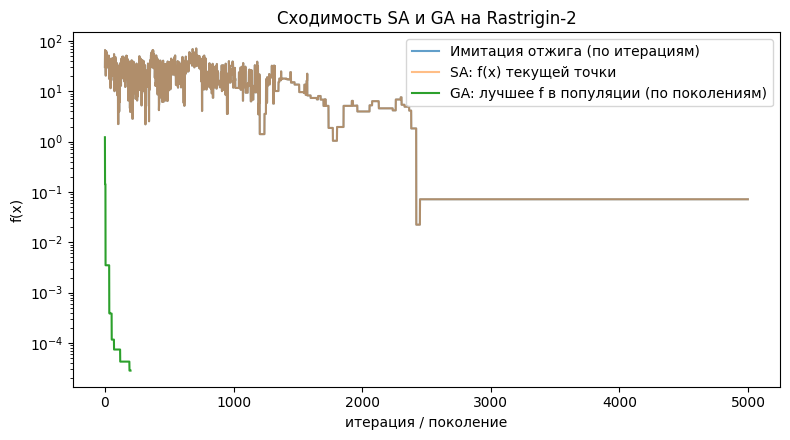

In [5]:
res_sa = simulated_annealing(BB2.Rastrigin2, x0=[4.5,-3.7], delta=0.8, gamma=0.998, max_iter=5000, seed=1)
res_ga = genetic_algorithm(BB2.Rastrigin2, bounds=[(-5.12,5.12)]*2, pop_size=40, n_parents=20, max_iter=200, seed=42)

plt.figure(figsize=(8,4.5))
plt.plot(res_sa["history"]["f"], label="Имитация отжига (по итерациям)", alpha=0.7)
# у GA считаем в терминах числа вызовов функции для честного сопоставления с SA
calls_per_gen = 40  # pop_size вызовов на поколение
ga_x = [i*calls_per_gen for i in range(len(res_ga["history"]["best_f"]))]
plt.plot(res_sa["history"]["f"], label="SA: f(x) текущей точки", alpha=0.5)
plt.plot(res_ga["history"]["best_f"], label="GA: лучшее f в популяции (по поколениям)")
plt.xlabel("итерация / поколение")
plt.ylabel("f(x)")
plt.yscale("log")
plt.title("Сходимость SA и GA на Rastrigin-2")
plt.legend()
plt.tight_layout()
plt.savefig("img/convergence_sa_ga_rastrigin.png")
plt.show()


## 4. Устойчивость имитации отжига к случайности (несколько запусков)

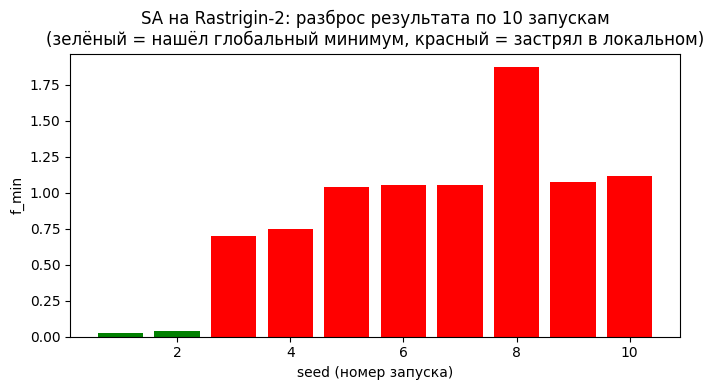

Среднее f_min: 0.8716244276605639
Доля успешных запусков (f_min < 0.5): 0.2


In [6]:
results_by_seed = []
for seed in range(1, 11):
    res = simulated_annealing(BB2.Rastrigin2, x0=[4.5,-3.7], delta=0.8, gamma=0.998, max_iter=5000, seed=seed)
    results_by_seed.append(res["f_min"])

plt.figure(figsize=(7,4))
plt.bar(range(1,11), results_by_seed, color=["green" if v < 0.5 else "red" for v in results_by_seed])
plt.xlabel("seed (номер запуска)")
plt.ylabel("f_min")
plt.title("SA на Rastrigin-2: разброс результата по 10 запускам\n(зелёный = нашёл глобальный минимум, красный = застрял в локальном)")
plt.tight_layout()
plt.savefig("img/sa_seed_variance.png")
plt.show()

print("Среднее f_min:", sum(results_by_seed)/len(results_by_seed))
print("Доля успешных запусков (f_min < 0.5):", sum(1 for v in results_by_seed if v < 0.5) / len(results_by_seed))


## 5. Графическое сравнение числа вызовов функции по всем методам

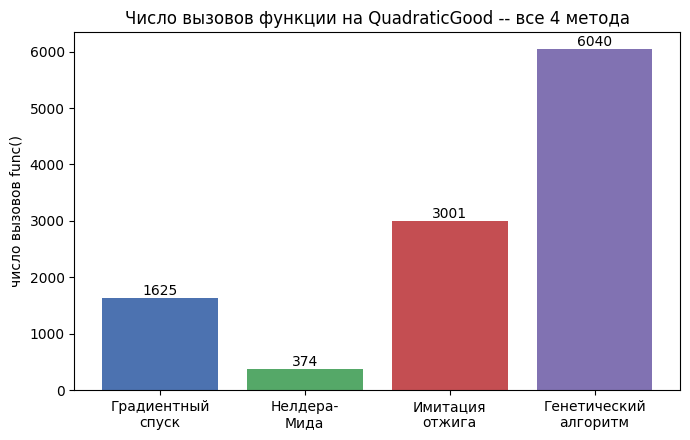

In [7]:
methods = ["Градиентный\nспуск", "Нелдера-\nМида", "Имитация\nотжига", "Генетический\nалгоритм"]
calls_quadgood = [1625, 374, 3001, 6040]  # из таблицы 1, QuadraticGood

plt.figure(figsize=(7,4.5))
bars = plt.bar(methods, calls_quadgood, color=["#4C72B0","#55A868","#C44E52","#8172B2"])
plt.ylabel("число вызовов func()")
plt.title("Число вызовов функции на QuadraticGood -- все 4 метода")
for bar, val in zip(bars, calls_quadgood):
    plt.text(bar.get_x()+bar.get_width()/2, val, str(val), ha="center", va="bottom")
plt.tight_layout()
plt.savefig("img/func_calls_comparison.png")
plt.show()
